# TerraLens: Dando una nueva visión al reciclaje.

In [20]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import regularizers
import cv2
import os

In [21]:
# Configuración de parámetros
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
DATASET_PATH = "/home/initmanfig/TerraLens/dataset-residuos"

In [22]:
# Carga de datos con split automático (80% tren, 20% validación)
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=1234,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=1234,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

Found 247 files belonging to 4 classes.
Using 198 files for training.
Found 247 files belonging to 4 classes.
Using 49 files for validation.


In [23]:
class_names = train_ds.class_names
print(class_names)

['Botellas_Plasticas', 'Latas_Metalicas', 'Mecato', 'Papel_Carton']


In [5]:
# Optimización de rendimiento
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

In [24]:
data_augmentation = tf.keras.Sequential([
    
    layers.RandomRotation(0.15),
    
    # Movimiento leve
    layers.RandomTranslation(0.1, 0.1),
    
    # Zoom leve
    layers.RandomZoom(0.1),
    
    # Flip SOLO horizontal (opcional)
    layers.RandomFlip("horizontal"),

    #Ajustes de iluminación (moderados)
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
])

In [25]:
base_model = applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

In [26]:
#Congelamos el modelo base (no se entrena, ya sabe ver formas)
base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Lambda(applications.resnet50.preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])


In [27]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_3 (Sequential)   (None, 224, 224, 3)       0         
                                                                 
 lambda_2 (Lambda)           (None, 224, 224, 3)       0         
                                                                 
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d_2  (None, 2048)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_6 (Dense)             (None, 512)               1049088   
                                                                 
 dense_7 (Dense)             (None, 256)               131328    
                                                      

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ]
)

Epoch 1/40


2026-04-21 00:23:52.271896: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-04-21 00:23:52.319104: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-21 00:23:54.788793: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f02c1e10e00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-21 00:23:54.788810: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4060, Compute Capability 8.9
2026-04-21 00:23:54.792516: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776749034.857596  105628 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


7/7 [==============================] - 10s 643ms/step - loss: 1.3592 - accuracy: 0.5051 - val_loss: 1.1473 - val_accuracy: 0.5306
Epoch 2/40
7/7 [==============================] - 1s 114ms/step - loss: 0.5961 - accuracy: 0.7980 - val_loss: 0.4060 - val_accuracy: 0.8571
Epoch 3/40
7/7 [==============================] - 1s 113ms/step - loss: 0.4070 - accuracy: 0.8434 - val_loss: 0.3946 - val_accuracy: 0.8980
Epoch 4/40
7/7 [==============================] - 1s 122ms/step - loss: 0.3412 - accuracy: 0.8889 - val_loss: 0.2853 - val_accuracy: 0.8776
Epoch 5/40
7/7 [==============================] - 1s 104ms/step - loss: 0.2171 - accuracy: 0.9192 - val_loss: 0.4559 - val_accuracy: 0.8571
Epoch 6/40
7/7 [==============================] - 1s 113ms/step - loss: 0.1489 - accuracy: 0.9545 - val_loss: 0.2501 - val_accuracy: 0.9388
Epoch 7/40
7/7 [==============================] - 1s 113ms/step - loss: 0.1530 - accuracy: 0.9394 - val_loss: 0.2239 - val_accuracy: 0.9184
Epoch 8/40
7/7 [==============

## Guardar el modelo

In [ ]:
model.save('~/clasificador.keras')

In [ ]:
# FASE 2: FINE-TUNING
base_model.trainable = True

# Congelar todas menos las últimas capas
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompilar con LR bajo
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Entrenamiento fino
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ]
)

In [ ]:
model.save('clasificador_v3.keras')

## Matriz de Confusion

Calculando predicciones... (esto puede tardar un poco)


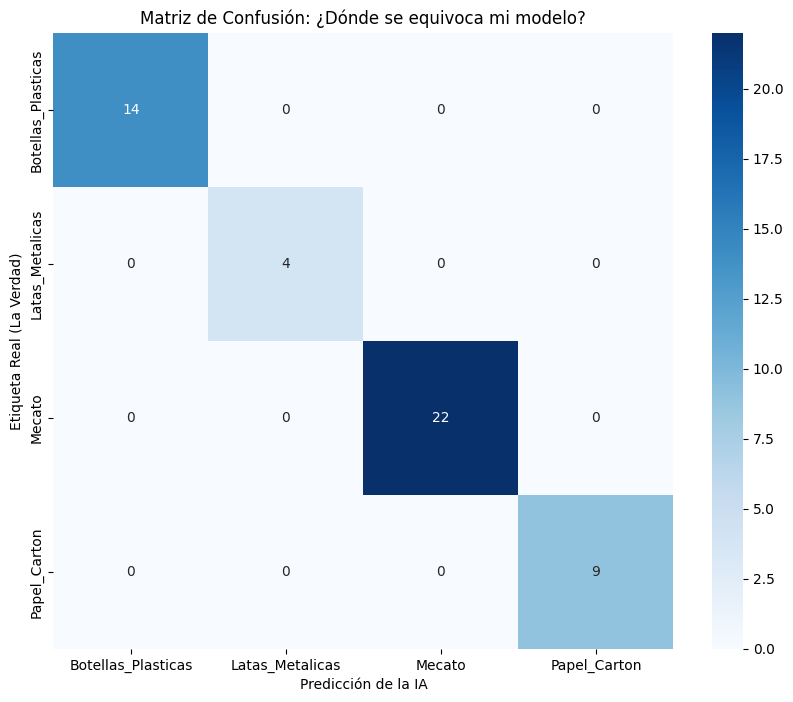


Reporte de Clasificación:
                    precision    recall  f1-score   support

Botellas_Plasticas       1.00      1.00      1.00        14
   Latas_Metalicas       1.00      1.00      1.00         4
            Mecato       1.00      1.00      1.00        22
      Papel_Carton       1.00      1.00      1.00         9

          accuracy                           1.00        49
         macro avg       1.00      1.00      1.00        49
      weighted avg       1.00      1.00      1.00        49



In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import os

model = model.load_weights("~/clasificador.keras")
# 1. Obtener las etiquetas reales (y_true) y las predicciones (y_pred)
y_true = []
y_pred = []

print("Calculando predicciones... (esto puede tardar un poco)")
for images, labels in val_ds:
    # Guardamos las etiquetas reales
    y_true.extend(np.argmax(labels, axis=1))

    # Hacemos la predicción y guardamos el índice con mayor probabilidad
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))

# 2. Configurar los nombres de las clases (en orden alfabético)
class_names = sorted(os.listdir(DATASET_PATH))

# 3. Crear la matriz
cm = confusion_matrix(y_true, y_pred)

# 4. Graficar usando Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción de la IA')
plt.ylabel('Etiqueta Real (La Verdad)')
plt.title('Matriz de Confusión: ¿Dónde se equivoca mi modelo?')
plt.show()

# 5. Imprimir reporte de métricas detallado
print("\nReporte de Clasificación:")
print(classification_report(y_true, y_pred, target_names=class_names))